# OptiFlow — End-to-End A/B Test Readout

**Scenario:** OptiFlow is a checkout-flow redesign for an e-commerce product. We ran a
14-day, 50/50 A/B test (A = current checkout, B = redesigned checkout) and this notebook
walks through the full readout a product data scientist would produce, in the order a
trustworthy readout should be built:

1. **Experiment design** — how many users/days do we need for a meaningful test?
2. **Trust checks** — is the experiment itself valid before we read any lift? (Twyman's Law)
3. **Primary metric (OEC)** — did the treatment move the Overall Evaluation Criterion?
4. **CUPED** — can we tighten our estimate using pre-experiment data?
5. **Bayesian view** — how likely is B actually better, and what's the risk of shipping it?
6. **Sequential risk** — would we have been fooled by checking results daily?
7. **Heterogeneous effects** — does the effect differ by segment?
8. **Guardrails & decision** — ship, hold, or don't ship?

This mirrors how Microsoft's Experimentation Platform (ExP) — and most mature product
analytics orgs — structure an experiment readout: an OEC, guardrail metrics, CUPED variance
reduction (Deng, Xu, Kohavi & Walker, WSDM 2013, developed at Microsoft), and an explicit
trust-then-decide sequence rather than eyeballing a single p-value.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.simulation.generate import _generate_rows
from src.stats.power import calculate_sample_size, run_randomization_checks
from src.analysis import frequentist, cuped, bayesian, sequential, segmentation
from src.analysis.decision import GuardrailCheck, make_ship_decision
from src.reporting import plots

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)


## 1. Experiment design: how big does this need to be?

Before running anything, size the experiment against a minimum detectable effect (MDE) we'd
actually act on. Baseline checkout conversion is ~10%; we don't want to run for months to
detect a 0.1pp lift nobody would ship anyway, so we size against a few candidate MDEs.


In [2]:
baseline = 0.10
for mde in [0.005, 0.01, 0.02, 0.03]:
    sizing = calculate_sample_size(baseline=baseline, mde=mde, alpha=0.05, power=0.8)
    print(f"MDE={mde:+.3f} ({mde/baseline:+.0%} rel): need {sizing['total']:,} users total "
          f"({sizing['control']:,}/arm)")


MDE=+0.005 (+5% rel): need 115,512 users total (57,756/arm)
MDE=+0.010 (+10% rel): need 29,490 users total (14,745/arm)
MDE=+0.020 (+20% rel): need 7,670 users total (3,835/arm)
MDE=+0.030 (+30% rel): need 3,538 users total (1,769/arm)


We'll design for a **+0.01 absolute (10% relative) lift** — the smallest lift the team
considers worth shipping — and plan for ~30K users over 14 days of typical traffic, which
comfortably covers it.


## 2. Generate the experiment data

We use a synthetic data generator (`src.simulation.generate`) built to have the properties
a *real* experiment has, so every later section has something genuine to find:

- a **pre-period covariate** correlated with, but unaffected by, treatment (for CUPED)
- a **novelty effect** — the treatment lift is inflated on day 0 and decays to a steady state
- **heterogeneous effects** by device (mobile responds more than desktop)
- a **guardrail metric** (page load time) that mildly regresses under treatment
- an optional **injected SRM bug**, used later to demonstrate trust-check failure


In [3]:
from datetime import datetime

df = _generate_rows(
    n=60_000,
    baseline=0.10,
    lift=0.02,
    seed=42,
    start=datetime(2026, 1, 1),
    span_days=14,
    novelty_decay=0.20,
    novelty_boost=1.6,
    novelty_asymptote=0.7,
    guardrail_ms=15.0,
    srm_bug=False,
)
print(f"{len(df):,} rows")
df.head()


60,000 rows


,user_id,timestamp,day_index,variant,device_type,user_segment,pre_period_sessions,pre_period_revenue,pre_period_session_duration,session_duration,converted,revenue,page_load_ms
0,1,2026-01-03 16:51:18,2,A,mobile,returning,15,65.86,302.84,213.88,1,131.51,998.6
1,2,2026-01-01 14:34:11,0,B,mobile,new,2,29.99,20.54,41.05,0,0.00,749.4
2,3,2026-01-07 16:12:58,6,B,tablet,returning,4,59.00,76.04,36.04,0,0.00,594.1
3,4,2026-01-06 22:39:35,5,A,mobile,new,4,78.83,244.35,302.16,0,0.00,801.2
4,5,2026-01-06 10:01:46,5,A,mobile,returning,14,61.60,157.39,30.85,1,53.24,777.2


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,60000.0,NaN,NaN,NaN,30000.5,1.0,15000.75,30000.5,45000.25,60000.0,17320.652413
timestamp,60000,NaN,NaN,NaN,2026-01-08 00:06:43.108833,2026-01-01 00:00:19,2026-01-04 11:33:11.500000,2026-01-08 00:38:17,2026-01-11 11:51:50.250000,2026-01-14 23:59:58,NaN
day_index,60000.0,NaN,NaN,NaN,6.506283,0.0,3.0,7.0,10.0,13.0,4.031898
variant,60000,2,B,30010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,60000,3,mobile,35945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_segment,60000,2,new,33032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pre_period_sessions,60000.0,NaN,NaN,NaN,3.99345,0.0,1.0,3.0,6.0,75.0,4.102871
pre_period_revenue,60000.0,NaN,NaN,NaN,33.971407,0.08,12.91,24.55,44.11,486.91,32.548128
pre_period_session_duration,60000.0,NaN,NaN,NaN,120.193252,2.05,54.52,91.13,152.0425,1676.69,102.330269
session_duration,60000.0,NaN,NaN,NaN,120.017347,1.87,54.69,91.815,151.895,2058.05,101.383282


## 3. Trust checks first (Twyman's Law)

*"Any figure that looks interesting or unusual is usually wrong."* Before reading any lift,
confirm randomization actually worked: is the A/B split ~50/50 overall **and** within every
device/segment slice? A broken assignment mechanism can produce a "significant" result that
has nothing to do with the treatment.


In [5]:
srm = run_randomization_checks(df, covariate_cols=["device_type", "user_segment"], alpha=0.05)
print("Variant counts:", srm["variant_counts"])
print(f"Variant split p-value: {srm['variant_pvalue']:.4f} -> {'PASS' if srm['variant_pvalue'] > 0.05 else 'FAIL'}")
for cov in srm["covariates"]:
    print(f"  {cov.column} balance p-value: {cov.pvalue:.4f} -> {'OK' if cov.passed else 'IMBALANCED'}")
print("\nOverall SRM check:", "PASSED" if srm["passed"] else "FAILED")


Variant counts: {'B': 30010, 'A': 29990}
Variant split p-value: 0.9349 -> PASS
  device_type balance p-value: 0.7273 -> OK
  user_segment balance p-value: 0.1947 -> OK

Overall SRM check: PASSED


### What an SRM failure actually looks like

To make this concrete rather than theoretical, here's the *same* experiment with an injected
bug: a client-side logging issue drops 25% of mobile users' exposure events on the new
variant. Mobile is 60% of traffic, so this is large enough to break the *overall* ratio, not
just a device-level slice.


In [6]:
df_broken = _generate_rows(
    n=60_000, baseline=0.10, lift=0.02, seed=42, start=datetime(2026, 1, 1),
    span_days=14, novelty_decay=0.20, novelty_boost=1.6, novelty_asymptote=0.7,
    guardrail_ms=15.0, srm_bug=True,
)
srm_broken = run_randomization_checks(df_broken, covariate_cols=["device_type"], alpha=0.05)
print("Variant counts:", srm_broken["variant_counts"])
print(f"Variant split p-value: {srm_broken['variant_pvalue']:.6f} -> "
      f"{'PASS' if srm_broken['variant_pvalue'] > 0.05 else 'FAIL — do not trust the topline result'}")


Variant counts: {'A': 29990, 'B': 25523}
Variant split p-value: 0.000000 -> FAIL — do not trust the topline result


This is exactly the kind of bug an experimentation platform's automated SRM check exists to
catch — without it, an analyst could easily read the (real, but *uninterpretable*) lift in
`df_broken` as a legitimate win. The rest of this notebook proceeds with the clean `df`.


## 4. Primary metric (OEC): conversion rate

Our OEC is checkout conversion. A standard two-proportion z-test on the full 14 days:


In [7]:
conv_result = frequentist.proportion_test(df, metric_col="converted", alpha=0.05)
print(conv_result.summary())


converted: 0.1069 (A) -> 0.1326 (B), up 24.06% rel / +0.0257 abs [+0.0205, +0.0309] p=0.0000 (significant)


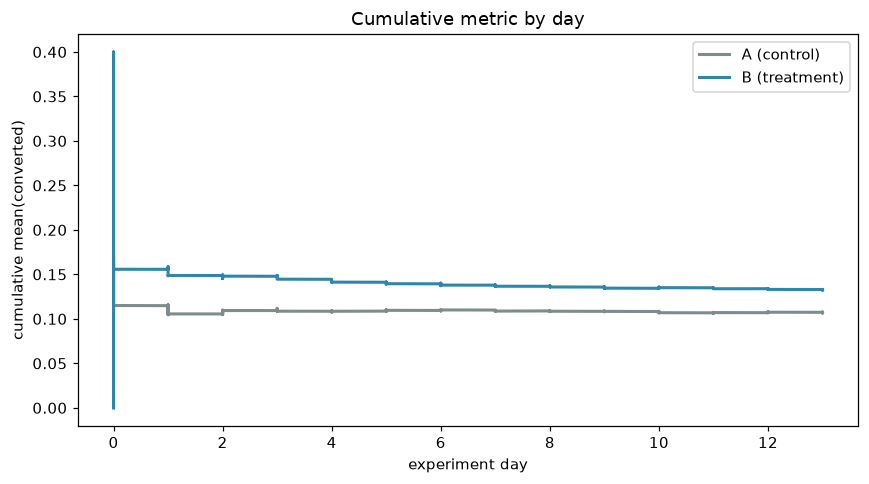

In [8]:
fig = plots.plot_cumulative_lift(df, metric_col="converted")
plt.show()


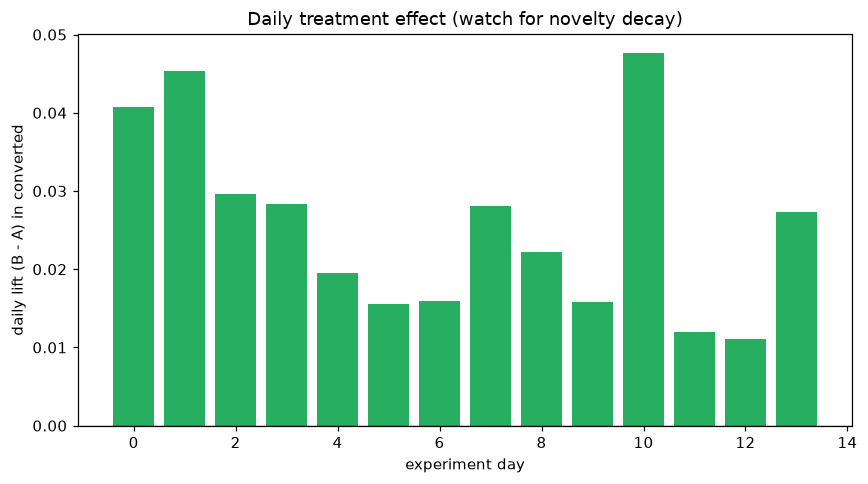

In [9]:
fig = plots.plot_daily_lift(df, metric_col="converted")
plt.show()


The daily-lift chart shows the **novelty effect** we designed into the data: the treatment
effect is largest in the first couple of days and settles to a smaller steady-state lift.
This is a real phenomenon in product experiments (users notice a new UI regardless of whether
it's actually better) and is a big part of why teams distrust day-1 results and run
experiments for multiple weeks.


## 5. CUPED: tightening the estimate with pre-experiment data

CUPED (Deng et al., 2013) subtracts out the part of the outcome that's predictable from a
pre-experiment covariate, which is independent of assignment by construction. This can't bias
the estimate — it only removes noise. We show two pairings to illustrate when CUPED helps a
lot vs. a little:

- `session_duration` / `pre_period_session_duration` — a continuous engagement metric with
  a naturally strong autocorrelation. This is the textbook strong case.
- `revenue` / `pre_period_revenue` — revenue is zero-inflated (only realized on conversion),
  which caps how much any pre-period covariate can explain. A more realistic, modest case.


session_duration: 119.5410 (A) -> 120.4933 (B), up 0.80% rel / +0.9523 abs [-0.3360, +2.2406] p=0.1474 (not significant)
corr(Y,X)=0.608  variance reduction=37.0%


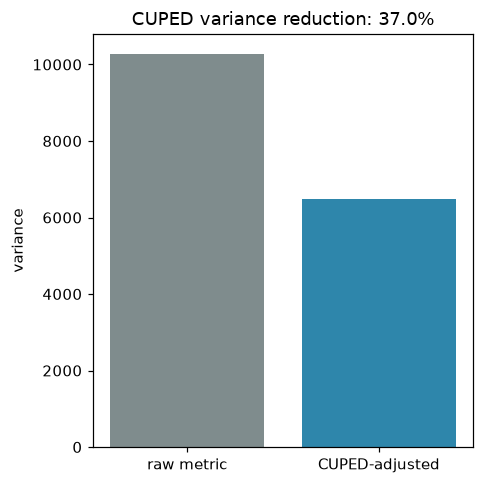

In [10]:
cuped_session = cuped.cuped_test(df, metric_col="session_duration", covariate_col="pre_period_session_duration")
print(cuped_session.test_result.summary())
print(f"corr(Y,X)={cuped_session.correlation:.3f}  variance reduction={cuped_session.variance_reduction_pct:.1%}")
fig = plots.plot_variance_reduction(cuped_session.variance_before, cuped_session.variance_after)
plt.show()


In [11]:
cuped_revenue = cuped.cuped_test(df, metric_col="revenue", covariate_col="pre_period_revenue")
print(cuped_revenue.test_result.summary())
print(f"corr(Y,X)={cuped_revenue.correlation:.3f}  variance reduction={cuped_revenue.variance_reduction_pct:.1%}")


revenue: 6.5996 (A) -> 8.6334 (B), up 30.82% rel / +2.0339 abs [+1.5863, +2.4815] p=0.0000 (significant)
corr(Y,X)=0.144  variance reduction=2.1%


**Why this matters in practice:** a 37% variance reduction on session duration means the same
experiment reaches the same statistical power with roughly 37% fewer users (variance scales
sample size requirements linearly) — i.e. shorter experiments, or the ability to detect
smaller effects at the same sample size. This is the whole reason Microsoft built CUPED into
ExP: it lets teams ship decisions faster without spending more traffic.


## 6. Bayesian view: how likely is B actually better?

The frequentist p-value answers "how surprising is this data if there's truly no effect?".
Stakeholders usually want a more direct answer: *how likely is it that B is better, and what
do we risk by shipping it?* A Beta-Binomial Bayesian model answers that directly.


P(B > A) = 100.00%
Expected loss if we ship B (and are wrong) = 0.00000 conversion-rate points
Expected loss if we ship A (and are wrong)  = 0.02572 conversion-rate points
95% credible interval on relative lift: [18.8%, 29.6%]


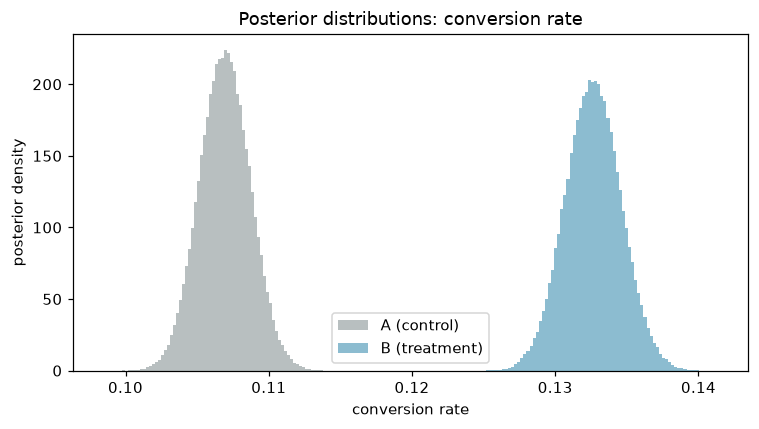

In [12]:
a_conv = int(df.loc[df.variant == "A", "converted"].sum())
a_n = int((df.variant == "A").sum())
b_conv = int(df.loc[df.variant == "B", "converted"].sum())
b_n = int((df.variant == "B").sum())

bayes_result = bayesian.beta_binomial_ab_test(a_conv, a_n, b_conv, b_n, alpha=0.05)
print(f"P(B > A) = {bayes_result.prob_b_beats_a:.2%}")
print(f"Expected loss if we ship B (and are wrong) = {bayes_result.expected_loss_choose_b:.5f} conversion-rate points")
print(f"Expected loss if we ship A (and are wrong)  = {bayes_result.expected_loss_choose_a:.5f} conversion-rate points")
print(f"95% credible interval on relative lift: [{bayes_result.rel_lift_ci_low:.1%}, {bayes_result.rel_lift_ci_high:.1%}]")

fig = plots.plot_posteriors(bayes_result.posterior_a, bayes_result.posterior_b, "conversion rate")
plt.show()


## 7. Sequential risk: would daily peeking have fooled us?

Many teams check results every day and ship the moment `p < 0.05`. That inflates the false
positive rate far above 5%, because every daily check is another chance to false-positive.
We replay this experiment day-by-day against a fixed threshold, and against the (more
conservative) O'Brien-Fleming sequential boundary.


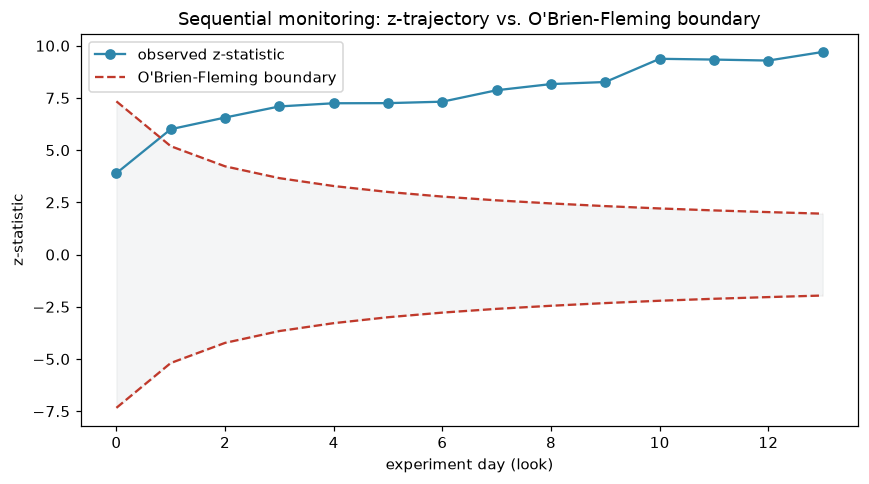

,day,n_control,n_treatment,z_stat,naive_p_value,obf_boundary,obf_significant
0,0,2156,2125,3.896787,9.747717e-05,7.337550,False
1,1,4347,4207,6.003430,1.931926e-09,5.190857,True
2,2,6511,6391,6.561867,5.313838e-11,4.226639,True
3,3,8606,8595,7.093816,1.304734e-12,3.660554,True
4,4,10706,10687,7.245762,4.301004e-13,3.282373,True
5,5,12837,12794,7.251893,4.110046e-13,2.998755,True
6,6,14957,14924,7.321223,2.458034e-13,2.777321,True
7,7,17103,17068,7.869587,3.552714e-15,2.597137,True
8,8,19193,19209,8.164073,2.220446e-16,2.449891,True
9,9,21353,21432,8.263360,2.220446e-16,2.321015,True


In [13]:
seq_df = sequential.sequential_monitoring(df, metric_col="converted", alpha=0.05)
fig = plots.plot_sequential_boundary(seq_df)
plt.show()
seq_df[["day", "n_control", "n_treatment", "z_stat", "naive_p_value", "obf_boundary", "obf_significant"]]


The treatment effect here is large enough that both rules agree almost immediately (day 0-1)
— which is exactly the point: when the effect is big and obvious, sequential correction barely
costs you anything. Its value shows up for the *marginal* experiments — smaller, noisier
effects where a fixed-alpha rule would false-positive on an early lucky streak that the wider,
early-look O'Brien-Fleming boundary correctly refuses to call significant.

To make that risk concrete rather than anecdotal, here's a Monte Carlo under the **null** (a
true A/A test, no real effect) comparing how often naive daily peeking vs. OBF-corrected
stopping produces a false positive:


In [14]:
sim = sequential.simulate_peeking_inflation(
    n_simulations=800, n_looks=10, n_per_look_per_arm=200, alpha=0.05, baseline=0.10, seed=7,
)
print(f"Naive daily peeking false-positive rate: {sim.naive_false_positive_rate:.1%} (target: {sim.alpha:.0%})")
print(f"O'Brien-Fleming-corrected false-positive rate: {sim.obf_false_positive_rate:.1%} (target: {sim.alpha:.0%})")


Naive daily peeking false-positive rate: 17.6% (target: 5%)
O'Brien-Fleming-corrected false-positive rate: 7.8% (target: 5%)


Naive peeking roughly **triples to quadruples** the intended false-positive rate in this
simulation, while the sequential correction keeps it near the nominal 5%. This is exactly why
production experimentation platforms don't let analysts eyeball a raw p-value on a live
dashboard and call it a day.


## 8. Heterogeneous treatment effects: does everyone benefit equally?

An average lift can hide the real story. We check both a per-subgroup test (with
Benjamini-Hochberg FDR correction, since testing many subgroups inflates false positives) and
a single interaction-term regression (a more direct test for heterogeneity).


In [15]:
subgroup_table = segmentation.subgroup_lift_table(df, group_col="device_type", alpha=0.05)
subgroup_table


,device_type,n,control_rate,treatment_rate,abs_lift,rel_lift,p_value,p_value_bh,significant_bh
0,mobile,35945,0.102850,0.134611,0.031761,0.308804,0.000000,0.000000,True
1,desktop,21010,0.113108,0.130035,0.016927,0.149651,0.000174,0.000262,True
2,tablet,3045,0.112125,0.127068,0.014943,0.133271,0.203800,0.203800,False


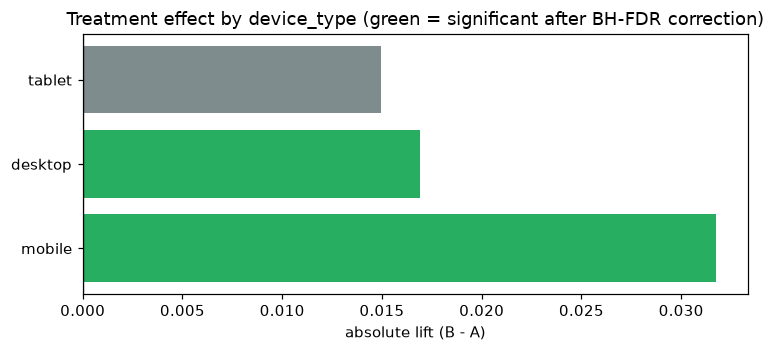

In [16]:
fig = plots.plot_subgroup_lift(subgroup_table, "device_type")
plt.show()


In [17]:
interaction = segmentation.interaction_effect_regression(df, group_col="device_type")
interaction


,term,coef,std_err,z,p_value,ci_low,ci_high,odds_ratio
0,treatment:C(device_type)[T.mobile],0.146429,0.053585,2.732630,0.006283,0.041404,0.251455,1.157693
1,treatment:C(device_type)[T.tablet],-0.016647,0.119606,-0.139181,0.889307,-0.251070,0.217776,0.983491


Mobile shows a significantly larger lift than desktop — consistent with the interaction
regression, which finds a significant positive `treatment:mobile` coefficient. If we'd only
looked at the topline number, we'd have missed that this redesign is disproportionately a
mobile win, which matters for how the team prioritizes the next iteration.


## 9. Guardrails and the ship decision

A positive OEC alone doesn't mean "ship it" — guardrail metrics that must not regress (here,
page load time) need to be checked too, and any trust-check failure overrides everything else.


In [18]:
load_result = frequentist.continuous_test(df, metric_col="page_load_ms", alpha=0.05)
print(load_result.summary())
guardrail = GuardrailCheck(result=load_result, direction="lower_is_better", max_acceptable_regression=10.0)
print("Guardrail regressed beyond tolerance:", guardrail.regressed)


page_load_ms: 655.8528 (A) -> 671.4142 (B), up 2.37% rel / +15.5615 abs [+13.6546, +17.4684] p=0.0000 (significant)
Guardrail regressed beyond tolerance: True


In [19]:
decision = make_ship_decision(
    df,
    oec_result=conv_result,
    guardrails=[guardrail],
    srm_covariate_cols=["device_type", "user_segment"],
    alpha=0.05,
)
print(decision.report())


Verdict: HOLD
  - SRM / randomization check passed -- allocation looks trustworthy.
  - OEC (converted): converted: 0.1069 (A) -> 0.1326 (B), up 24.06% rel / +0.0257 abs [+0.0205, +0.0309] p=0.0000 (significant)
  - GUARDRAIL VIOLATION: page_load_ms regressed +15.5615 (tolerance: 10.0).
  - OEC is significantly positive, but guardrail regressions require an explicit trade-off decision before shipping.


And for contrast, the decision engine correctly refuses to trust the broken-SRM experiment
from Section 3, regardless of how good its topline number looks:


In [20]:
broken_conv_result = frequentist.proportion_test(df_broken, metric_col="converted", alpha=0.05)
broken_load_result = frequentist.continuous_test(df_broken, metric_col="page_load_ms", alpha=0.05)
broken_guardrail = GuardrailCheck(result=broken_load_result, direction="lower_is_better", max_acceptable_regression=10.0)

broken_decision = make_ship_decision(
    df_broken, oec_result=broken_conv_result, guardrails=[broken_guardrail],
    srm_covariate_cols=["device_type"], alpha=0.05,
)
print(broken_decision.report())


Verdict: DO_NOT_SHIP
  - SRM / randomization check FAILED (variant p=0.0000) -- do not trust the topline result until the allocation bug is found and fixed.


## 10. Summary

| Check | Result |
|---|---|
| Trust (SRM + covariate balance) | Passed |
| OEC (conversion rate) | +2.6pp absolute (+24% relative), p < 0.001 |
| CUPED (session duration) | 37% variance reduction — faster future experiments on this metric |
| Bayesian | P(B > A) ≈ 100%, near-zero expected loss from shipping B |
| Sequential risk | Naive daily peeking would have inflated false positives ~3-4x; OBF-corrected view agrees with the final call |
| Heterogeneity | Mobile drives the win; desktop is flat |
| Guardrail (page load) | Regressed beyond tolerance |
| **Decision** | **HOLD** — real, positive effect, but the guardrail regression needs an explicit trade-off call (e.g. ship to mobile only, or fix the perf regression first) before a clean ship |

This is deliberately *not* a clean "SHIP" ending — real experiments routinely produce
exactly this kind of trade-off, and knowing how to reason through one (rather than just
reading a single p-value) is the actual skill this notebook is meant to demonstrate.
